In [73]:
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [75]:
phys = xr.open_dataset('Reshapr/SalishSeaCast_month_avg_phys_JdFmouth_20070101_20260531.nc')
chem = xr.open_dataset('Reshapr/SalishSeaCast_month_avg_chem_JdFmouth_20070101_20260531.nc')
biol = xr.open_dataset('Reshapr/SalishSeaCast_month_avg_biol_JdFmouth_20070101_20260531.nc')

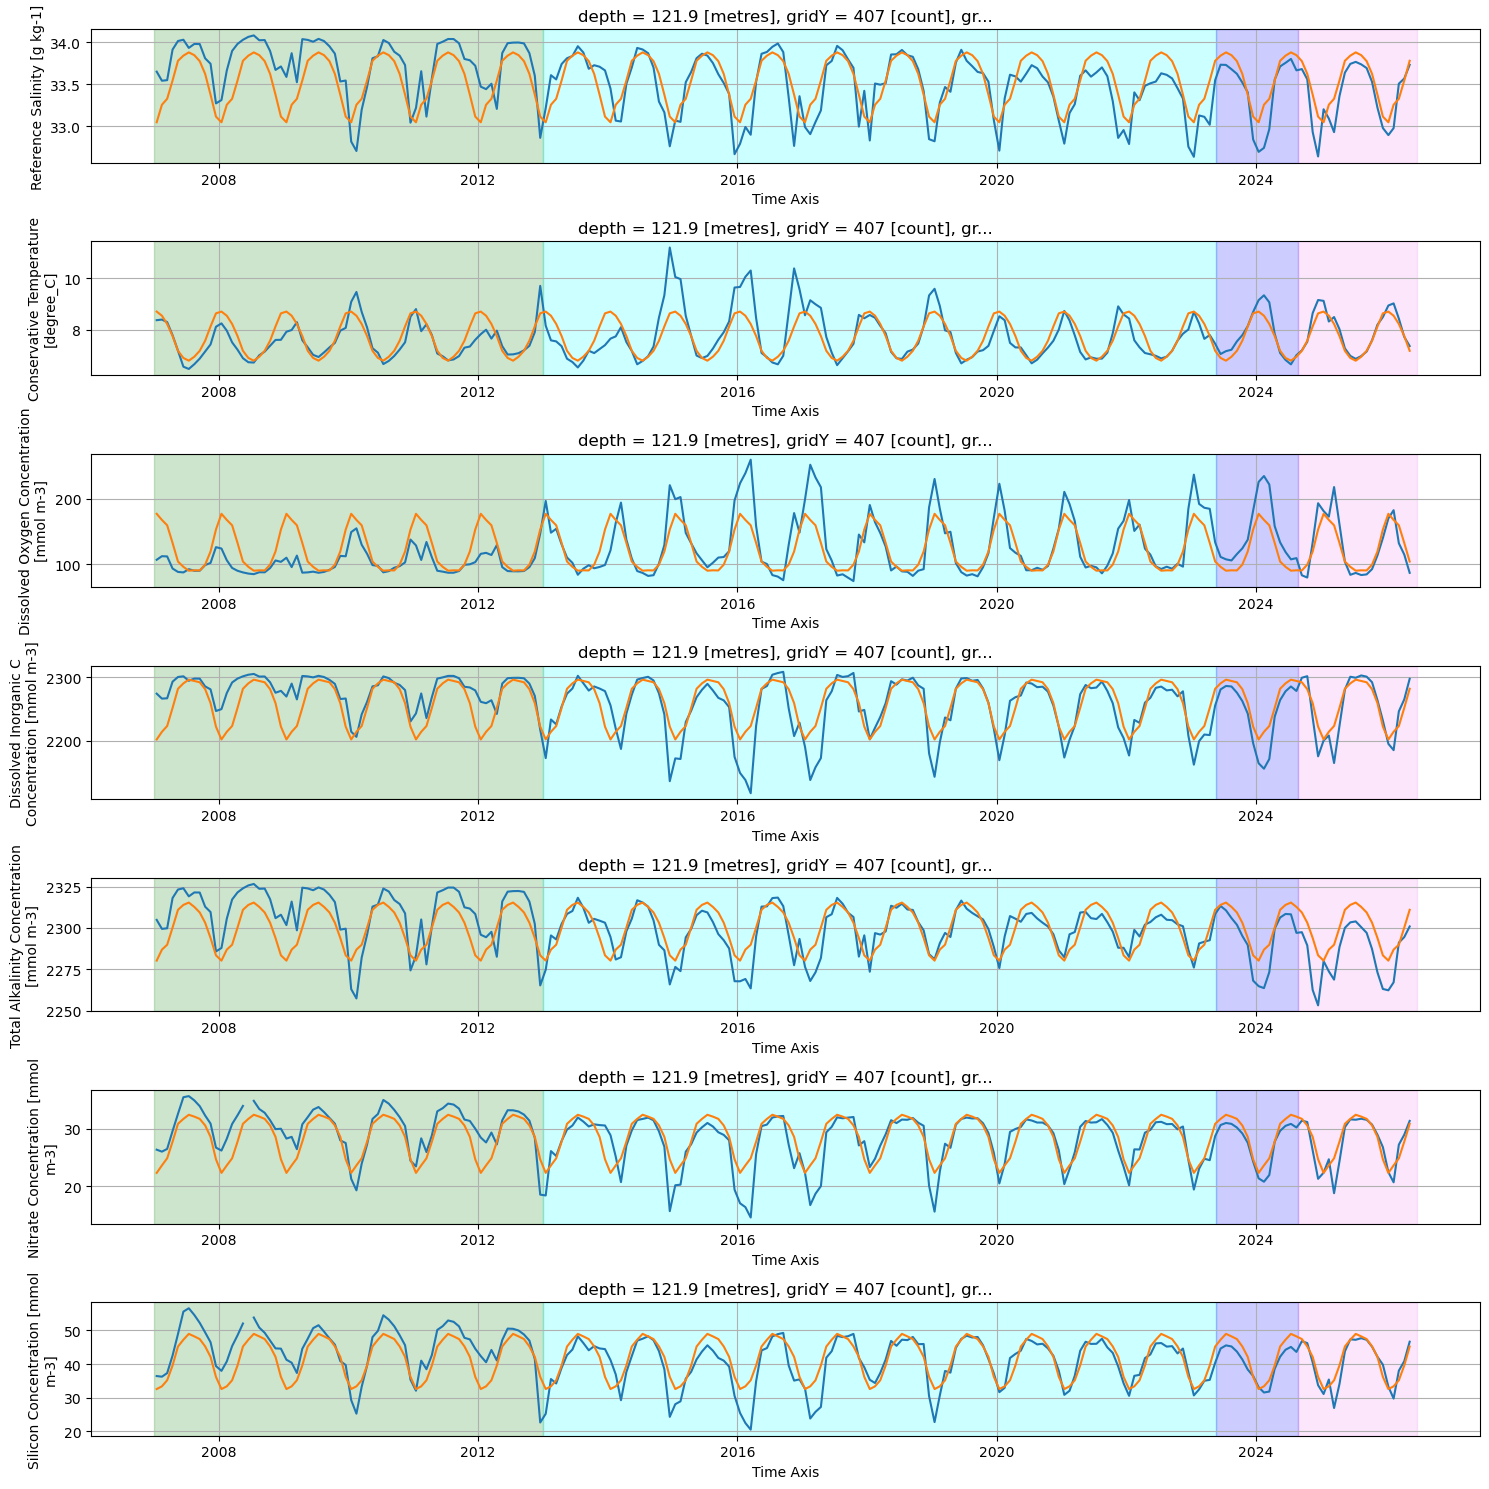

In [80]:
fig, axs = plt.subplots(7, 1, figsize=(15, 15))

# Salinity
phys.vosaline.plot(ax=axs[0])
axs[0].plot(phys.vosaline.time, np.tile(phys.vosaline.groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

# Temperature
phys.votemper.plot(ax=axs[1])
axs[1].plot(phys.votemper.time, np.tile(phys.votemper.groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

# Oxygen
chem.dissolved_oxygen.plot(ax=axs[2])
axs[2].plot(chem.dissolved_oxygen.time, np.tile(chem.dissolved_oxygen.groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

# DIC
ax = axs[3]
chem.dissolved_inorganic_carbon.plot(ax=ax)
ax.plot(chem.dissolved_inorganic_carbon.time, np.tile(chem.dissolved_inorganic_carbon.groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

# TA
ax = axs[4]
field = 'total_alkalinity'
chem[field].plot(ax=ax)
ax.plot(chem[field].time, np.tile(chem[field].groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

# Nitrate
ax = axs[5]
field = 'nitrate'
biol[field].plot(ax=ax)
ax.plot(biol[field].time, np.tile(biol[field].groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

# Silicon
ax = axs[6]
field = 'silicon'
biol[field].plot(ax=ax)
ax.plot(biol[field].time, np.tile(biol[field].groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);

for ax in axs:
    ax.grid()
    ax.axvspan(dt.datetime(2007, 1, 1), dt.datetime(2012, 12, 31), color='green', alpha=0.2, label='NEP')
    ax.axvspan(dt.datetime(2013, 1, 1), dt.datetime(2023, 5, 21), color='cyan', alpha=0.2, label='LiveOcean V1')
    ax.axvspan(dt.datetime(2023, 5, 22), dt.datetime(2024, 8, 25), color='blue', alpha=0.2, label='LiveOcean V2')
    ax.axvspan(dt.datetime(2024, 8, 26), dt.datetime(2026, 6, 25), color='violet', alpha=0.2, label='spun up LiveOcean V2')
fig.tight_layout();

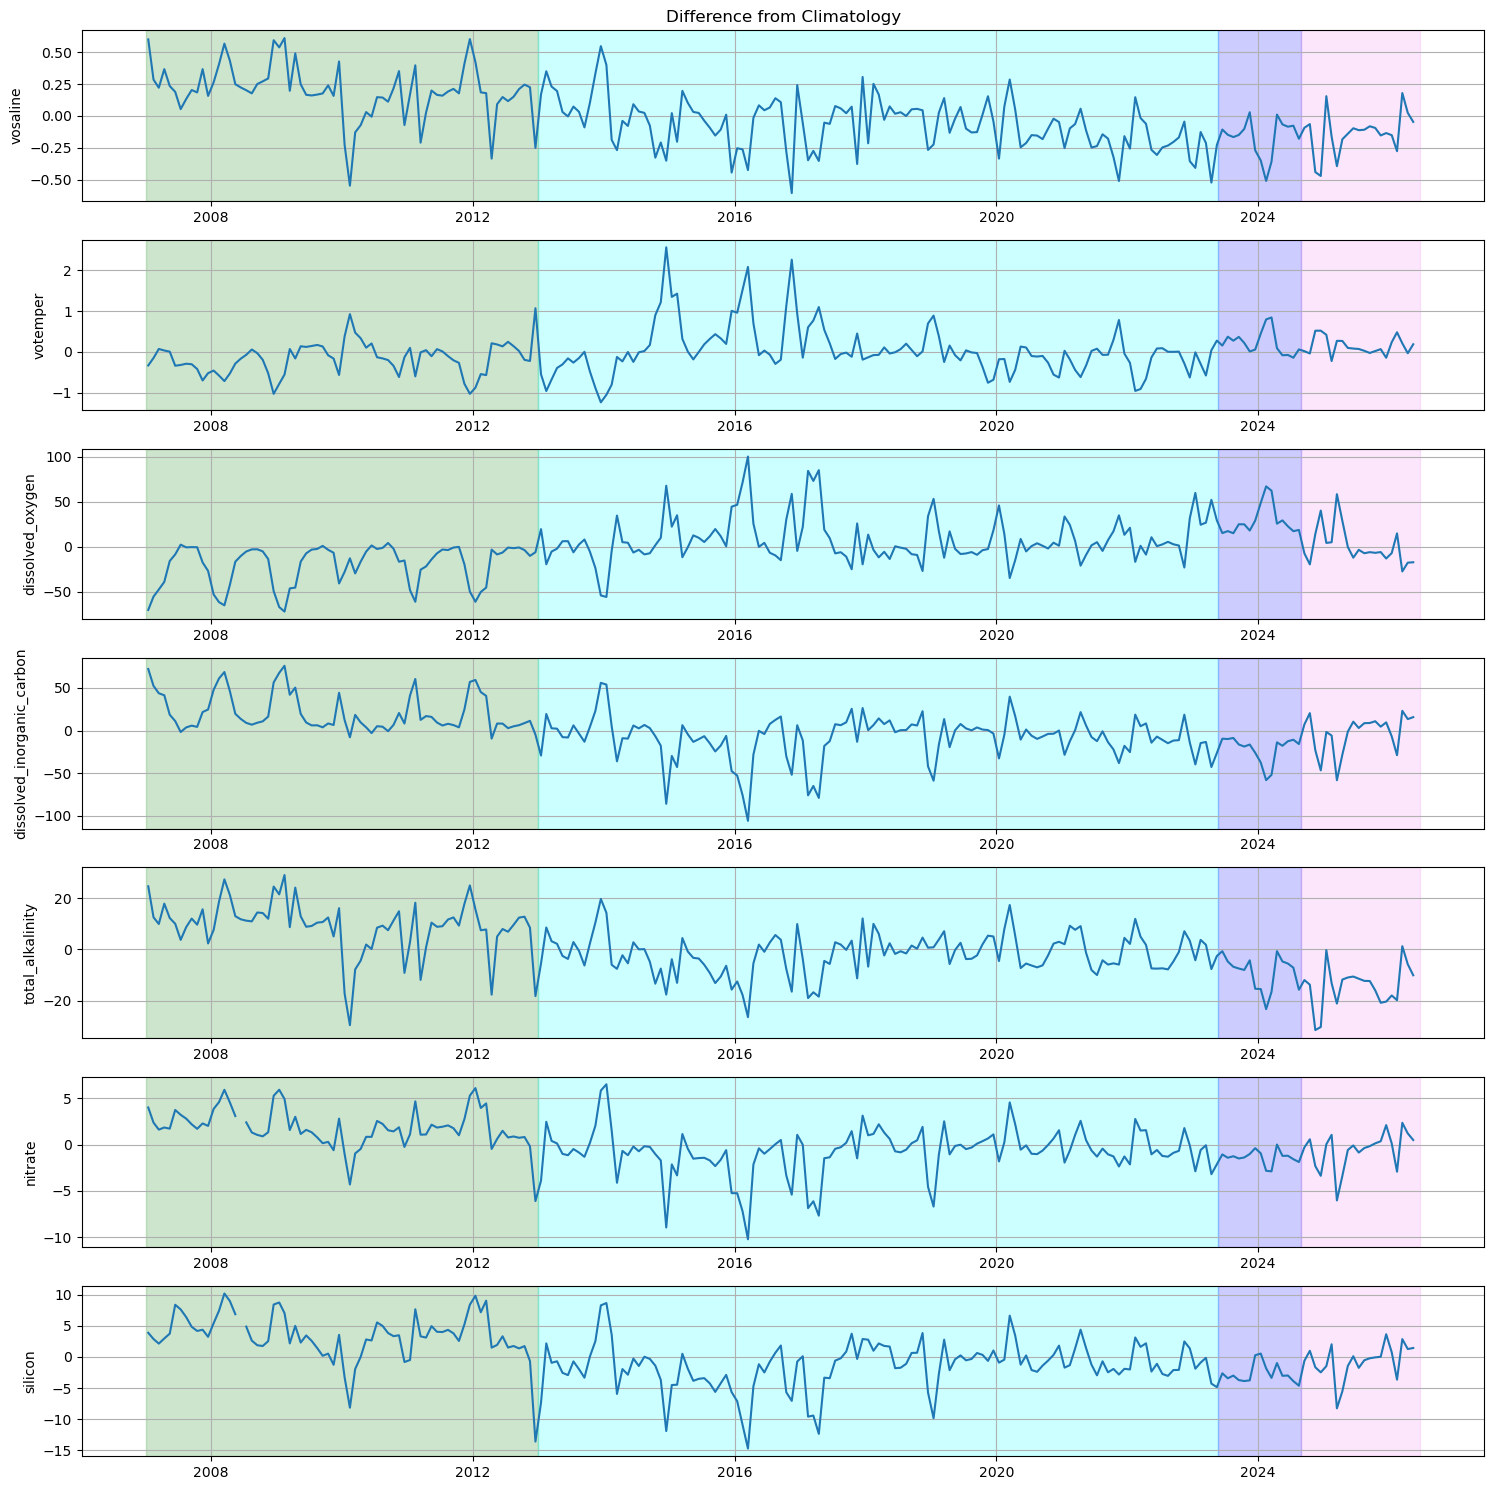

In [93]:
fig, axs = plt.subplots(7, 1, figsize=(15, 15))

# Salinity, Temperature
for ax, field, ds in zip(axs, 
                         ['vosaline', 'votemper', 'dissolved_oxygen', 'dissolved_inorganic_carbon', 'total_alkalinity',
                         'nitrate', 'silicon'], 
                         [phys, phys, chem, chem, chem, biol, biol]):
    ax.plot(ds[field].time, np.array(ds[field][:, 0, 0, 0]) - np.tile(ds[field].groupby('time.month').mean('time')[:, 0, 0, 0], 20)[:-7]);
    ax.set_ylabel(field)

axs[0].set_title('Difference from Climatology')

for ax in axs:
    ax.grid()
    ax.axvspan(dt.datetime(2007, 1, 1), dt.datetime(2012, 12, 31), color='green', alpha=0.2, label='NEP')
    ax.axvspan(dt.datetime(2013, 1, 1), dt.datetime(2023, 5, 21), color='cyan', alpha=0.2, label='LiveOcean V1')
    ax.axvspan(dt.datetime(2023, 5, 22), dt.datetime(2024, 8, 25), color='blue', alpha=0.2, label='LiveOcean V2')
    ax.axvspan(dt.datetime(2024, 8, 26), dt.datetime(2026, 6, 25), color='violet', alpha=0.2, label='spun up LiveOcean V2')
fig.tight_layout();

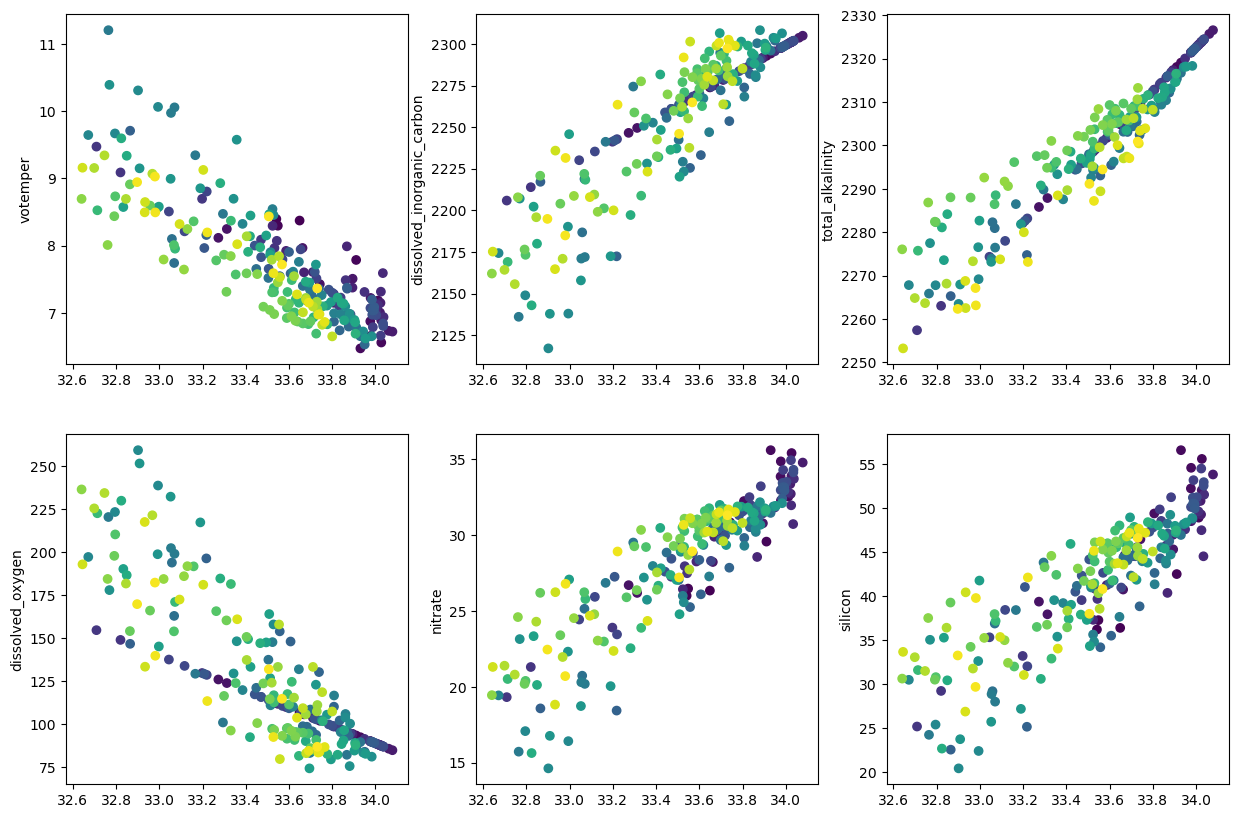

In [111]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

colours = np.arange(phys.vosaline.shape[0])

for iax, jax, field, ds in zip([0, 0, 0, 1, 1, 1], [0, 1, 2, 0, 1, 2], 
                               ['votemper', 'dissolved_inorganic_carbon', 'total_alkalinity', 
                                'dissolved_oxygen', 'nitrate', 'silicon'], [phys, chem, chem, chem, biol, biol]):
    axs[iax, jax].scatter(phys.vosaline[:, 0, 0, 0], ds[field][:, 0, 0, 0], c=colours)
    axs[iax, jax].set_ylabel(field)